# ElbowSig tutorial

This notebook demonstrates the use of `ElbowSig`.

### Preliminaries

Calling necessary function

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

import ElbowSig as ElbowSig


c:\Users\fjpre\OneDrive - University of Aberdeen\Work\Clustering_MultiScale\Codes\ElbowSig_package_1\ElbowSig.py:131: SyntaxWarning: invalid escape sequence '\d'
  ax[1].set_ylabel('$\delta_k$')
c:\Users\fjpre\OneDrive - University of Aberdeen\Work\Clustering_MultiScale\Codes\ElbowSig_package_1\ElbowSig.py:193: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('$\delta_k$')


## Example

Generating synthetic data:

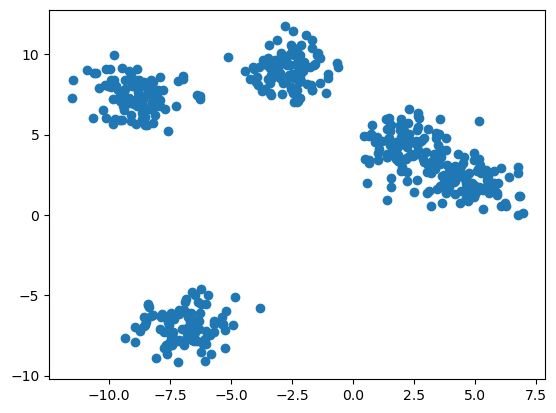

In [3]:
from sklearn.datasets import make_blobs

# Synthetic data
X, y = make_blobs(n_samples=500, centers=5, cluster_std=1, random_state=42)

plt.plot(X[:, 0], X[:, 1], 'o')

#### k-means

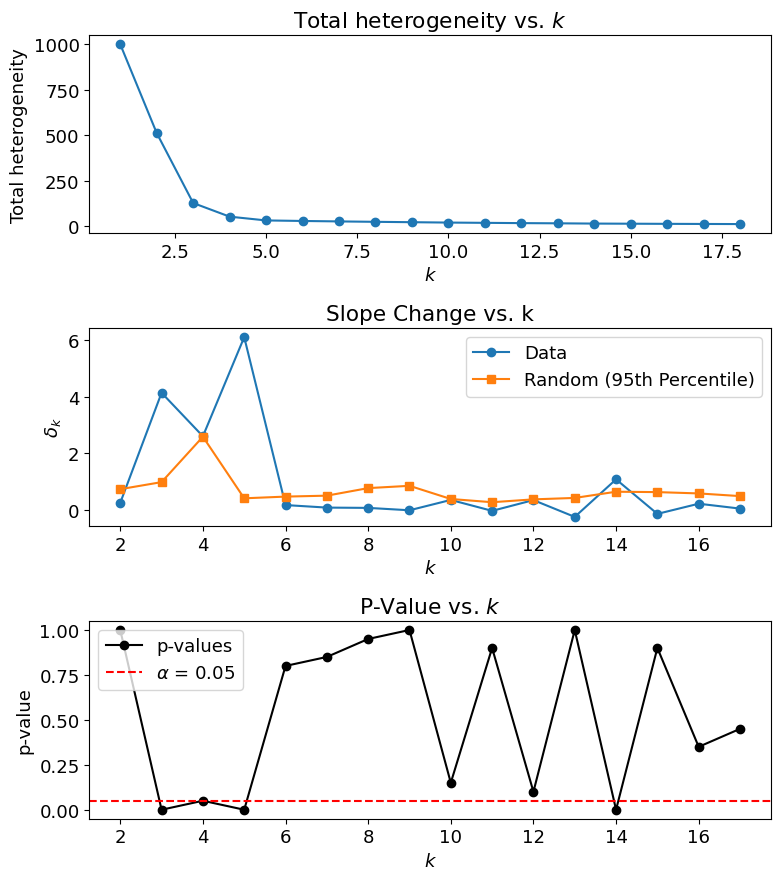

p-values:  [1.   0.   0.05 0.   0.8  0.85 0.95 1.   0.15 0.9  0.1  1.   0.   0.9
 0.35 0.45]


In [12]:
#k_values0, slope_change0, mean_slope_change, sd_slope_change, percentile, p_values, slope_change_distribution 
out = ElbowSig.Elbow_significance_general(
    X=X,
    kmax=18,
    nr=20,
    alpha=0.05,
    plotYN='y',
    random_state=42,
    heterogeneity_func=ElbowSig.Kmeans_Heterogeneity,
    pars=[20]
)

#Kmeans_Heterogeneity(X, k, random_state=42, pars=[10])

print('p-values: ', out['p_values'])

#### Agglomerative

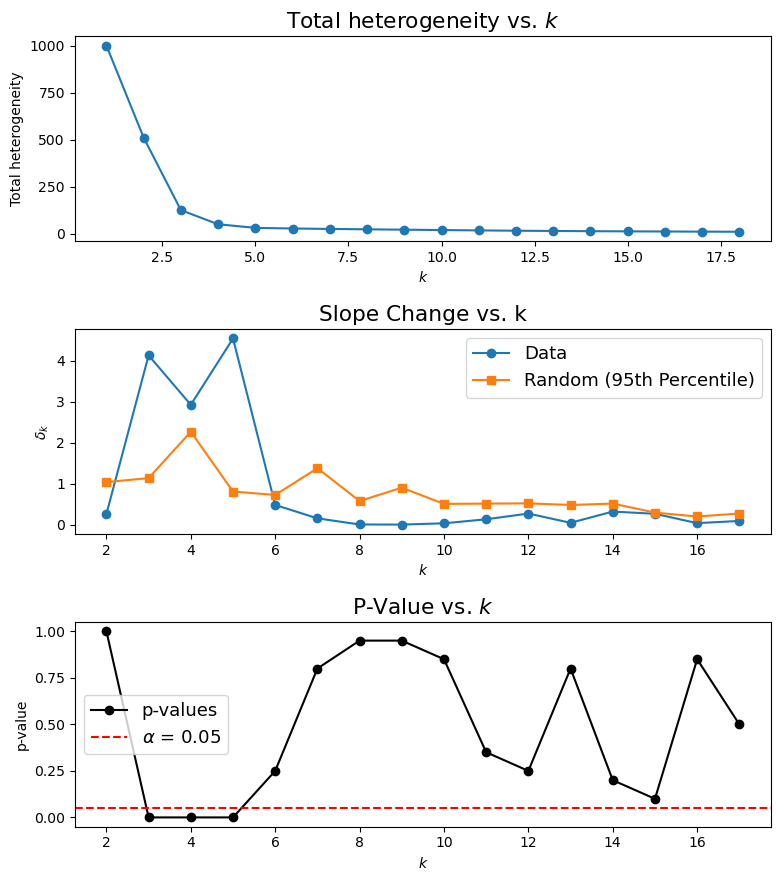

p-values:  [1.   0.   0.   0.   0.25 0.8  0.95 0.95 0.85 0.35 0.25 0.8  0.2  0.1
 0.85 0.5 ]


In [4]:
#k_values0, slope_change0, mean_slope_change, sd_slope_change, percentile, p_values, slope_change_distribution 
out = ElbowSig.Elbow_significance_general(
    X=X,
    kmax=18,
    nr=20,
    alpha=0.05,
    plotYN='y',
    random_state=42,
    heterogeneity_func=ElbowSig.Agglomerative_Heterogeneity,
    pars=['euclidean', 'ward']
)

#Agglomerative_Heterogeneity(X, k, random_state=42, pars=['euclidean', 'ward'])


print('p-values: ', out['p_values'])

Colouring the data based on clusters:

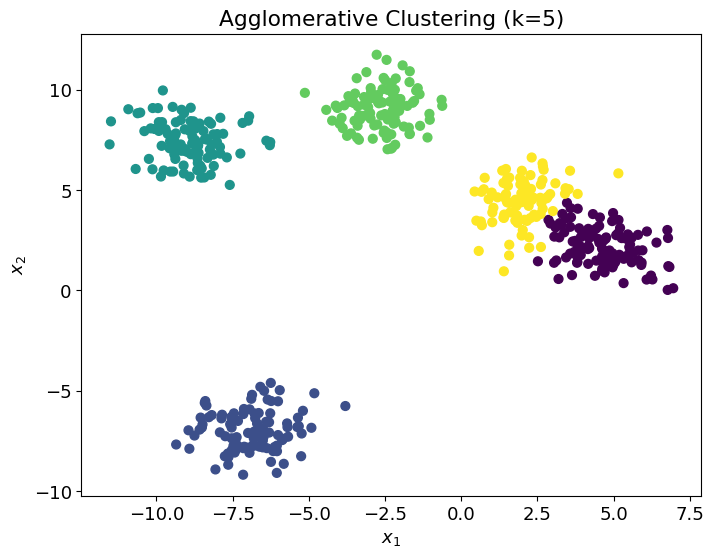

In [8]:
k = 5
ElbowSig.visualize_agglomerative_clustering(X, k)

#### Fuzzy c-means

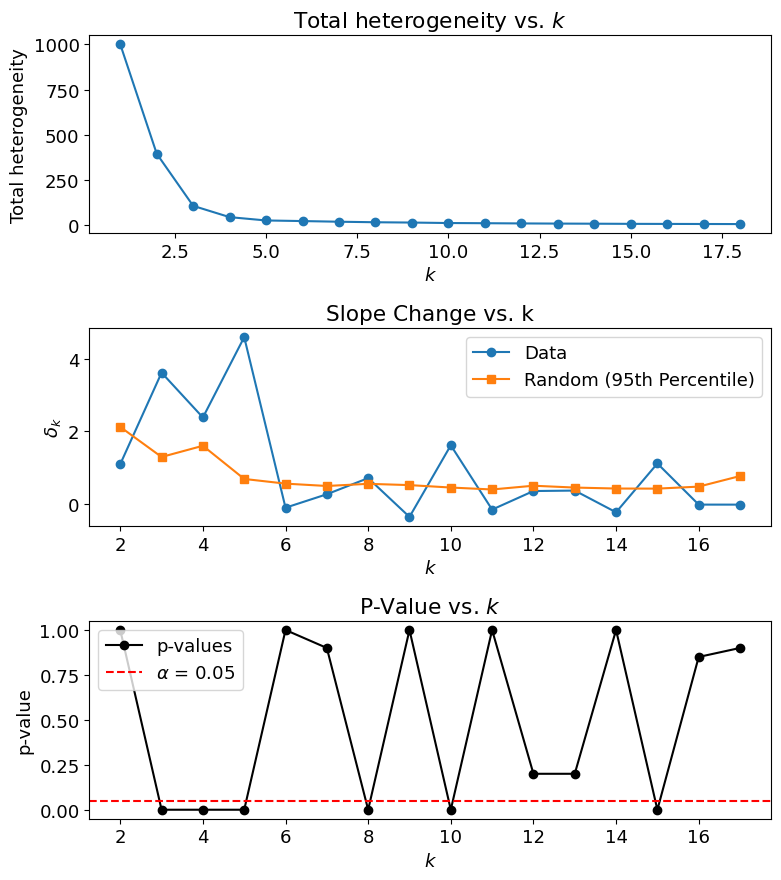

p-values:  [1.   0.   0.   0.   1.   0.9  0.   1.   0.   1.   0.2  0.2  1.   0.
 0.85 0.9 ]


In [9]:
out = ElbowSig.Elbow_significance_general(
    X=X,
    kmax=18,
    nr=20,
    alpha=0.05,
    plotYN='y',
    random_state=42,
    heterogeneity_func=ElbowSig.FCM_Heterogeneity,
    pars=[2, 0.005, 1000]
)

#X, kmax=10, nr=100, alpha=0.05, plotYN=True, random_state=42, heterogeneity_func=FCM_Heterogeneity,pars=[2, 0.005, 1000]

print('p-values: ', out['p_values'])

#### Gaussian Mixture Model

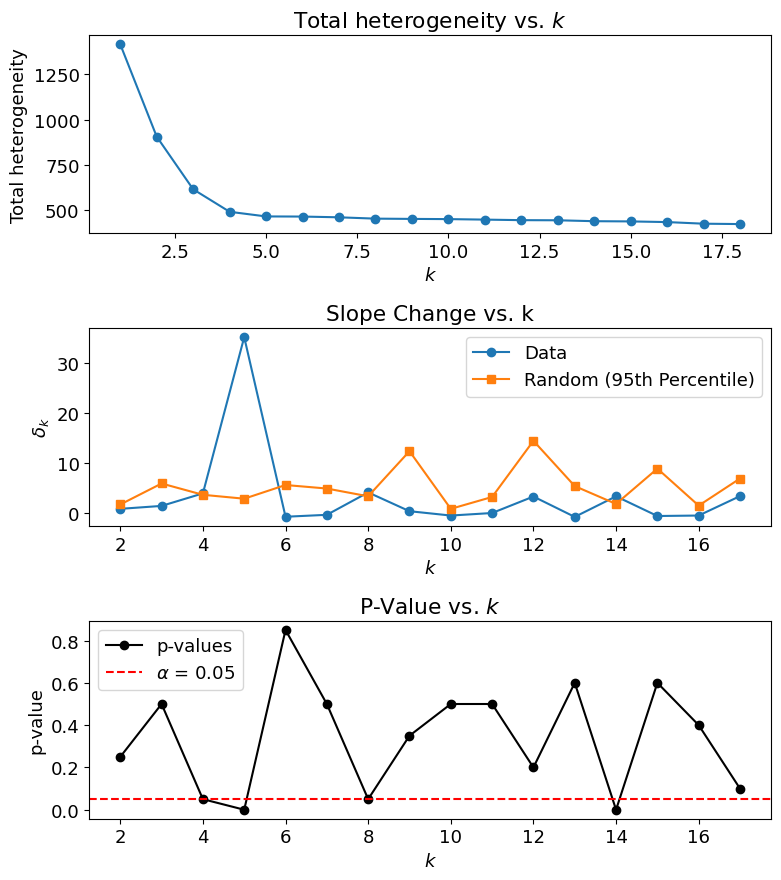

p-values:  [0.25 0.5  0.05 0.   0.85 0.5  0.05 0.35 0.5  0.5  0.2  0.6  0.   0.6
 0.4  0.1 ]


In [11]:
#k_values0, slope_change0, mean_slope_change, sd_slope_change, percentile, p_values, slope_change_distribution 
out = ElbowSig.Elbow_significance_general(
    X=X,
    kmax=18,
    nr=20,
    alpha=0.05,
    plotYN='y',
    random_state=42,
    heterogeneity_func=ElbowSig.GMM_Heterogeneity,
    pars=['full']
)

#GMM_Heterogeneity(X, k, random_state=42, pars=['full'])

print('p-values: ', out['p_values'])